In [1]:
!pip -q install tensorflow-datasets hdbscan

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from itertools import combinations

import tensorflow_datasets as tfds

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.random_projection import SparseRandomProjection
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception as e:
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN not available:", e)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
train_ds = tfds.load("ag_news_subset", split="train", as_supervised=True)

texts = []
y_true = []

MAX_DOCS = 12000

for i, (text, label) in enumerate(tfds.as_numpy(train_ds)):
    texts.append(text.decode("utf-8"))
    y_true.append(int(label))
    if MAX_DOCS is not None and len(texts) >= MAX_DOCS:
        break

y_true = np.array(y_true)

target_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Documents:", len(texts))
print("Classes:", len(set(y_true)), target_names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.PQ6W7R_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.PQ6W7R_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.
Documents: 12000
Classes: 4 ['World', 'Sports', 'Business', 'Sci/Tech']


In [4]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_tfidf = vectorizer.fit_transform(texts)
X_tfidf = normalize(X_tfidf, norm="l2", axis=1)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (12000, 30000)


In [5]:
JL_DIM = 512

rp = SparseRandomProjection(
    n_components=JL_DIM,
    dense_output=True,
    random_state=42
)

t0 = time.perf_counter()
X_jl = rp.fit_transform(X_tfidf)
jl_time = time.perf_counter() - t0

X_jl = normalize(X_jl, norm="l2", axis=1)

print("JL shape:", X_jl.shape)
print("JL transform time:", jl_time)

JL shape: (12000, 512)
JL transform time: 0.986692182999974


Mean abs distortion: 0.03465408843725476
95% abs distortion: 0.0867910280272603


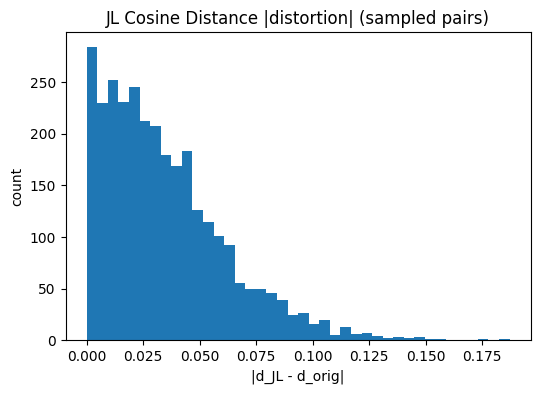

In [6]:
rng = np.random.default_rng(0)
n = X_tfidf.shape[0]
pairs = 3000

idx_a = rng.integers(0, n, size=pairs)
idx_b = rng.integers(0, n, size=pairs)

orig_sim = np.array([X_tfidf[i].multiply(X_tfidf[j]).sum() for i, j in zip(idx_a, idx_b)])
orig_dist = 1.0 - orig_sim

jl_sim = np.sum(X_jl[idx_a] * X_jl[idx_b], axis=1)
jl_dist = 1.0 - jl_sim

distortion = jl_dist - orig_dist
abs_distortion = np.abs(distortion)

print("Mean abs distortion:", abs_distortion.mean())
print("95% abs distortion:", np.quantile(abs_distortion, 0.95))

plt.figure(figsize=(6,4))
plt.hist(abs_distortion, bins=40)
plt.title("JL Cosine Distance |distortion| (sampled pairs)")
plt.xlabel("|d_JL - d_orig|")
plt.ylabel("count")
plt.show()

In [7]:
k = len(np.unique(y_true))

t0 = time.perf_counter()
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_km = kmeans.fit_predict(X_jl)
km_time = time.perf_counter() - t0

print("KMeans time:", km_time)

if HDBSCAN_AVAILABLE:
    t0 = time.perf_counter()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=15,
        min_samples=5,
        metric="euclidean"
    )
    y_hdb = clusterer.fit_predict(X_jl)
    hdb_time = time.perf_counter() - t0

    print("HDBSCAN time:", hdb_time)
    print("HDBSCAN clusters (excluding -1 noise):", len(set(y_hdb)) - (1 if -1 in y_hdb else 0))
else:
    y_hdb = None
    hdb_time = None

KMeans time: 14.63556138399997
HDBSCAN time: 215.65382239499996
HDBSCAN clusters (excluding -1 noise): 35


In [8]:
def random_hyperplane_hash(X, hyperplanes):
    proj = X @ hyperplanes.T
    return proj >= 0.0

def bits_to_int(bit_row):
    out = 0
    for b in bit_row:
        out = (out << 1) | int(b)
    return out

def lsh_candidate_buckets(bits, band_size):
    n, n_bits = bits.shape
    assert n_bits % band_size == 0
    n_bands = n_bits // band_size

    tables = []
    for b in range(n_bands):
        start = b * band_size
        end = start + band_size
        table = defaultdict(list)
        for i in range(n):
            key = bits_to_int(bits[i, start:end])
            table[key].append(i)
        tables.append(table)
    return tables

def build_candidate_pairs(tables, max_bucket_size=200):
    cand = set()
    for table in tables:
        for _, idxs in table.items():
            if len(idxs) < 2:
                continue
            if len(idxs) > max_bucket_size:
                continue
            for i, j in combinations(idxs, 2):
                if i < j:
                    cand.add((i, j))
                else:
                    cand.add((j, i))
    return cand

def connected_components(n, edges):
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, j in edges:
        union(i, j)

    roots = np.array([find(i) for i in range(n)])
    _, labels = np.unique(roots, return_inverse=True)
    return labels

In [9]:
N_BITS = 96
BAND_SIZE = 12
COS_THRESHOLD = 0.65
MAX_BUCKET = 250

rng = np.random.default_rng(42)
d = X_jl.shape[1]

hyperplanes = rng.normal(size=(N_BITS, d)).astype(np.float32)
hyperplanes /= np.linalg.norm(hyperplanes, axis=1, keepdims=True) + 1e-12

t0 = time.perf_counter()

bits = random_hyperplane_hash(X_jl, hyperplanes)
tables = lsh_candidate_buckets(bits, band_size=BAND_SIZE)
cand_pairs = build_candidate_pairs(tables, max_bucket_size=MAX_BUCKET)

mid = time.perf_counter()

edges = []
for (i, j) in cand_pairs:
    sim = float(np.dot(X_jl[i], X_jl[j]))
    if sim >= COS_THRESHOLD:
        edges.append((i, j))

y_lsh = connected_components(n=X_jl.shape[0], edges=edges)

lsh_time = time.perf_counter() - t0
hash_time = mid - t0
refine_time = lsh_time - hash_time

print("LSH candidates:", len(cand_pairs))
print("LSH edges kept:", len(edges))
print("LSH clusters:", len(np.unique(y_lsh)))
print("LSH time total:", lsh_time)
print("Hash time:", hash_time)
print("Refine time:", refine_time)

LSH candidates: 154966
LSH edges kept: 441
LSH clusters: 11707
LSH time total: 1.8528791490000458
Hash time: 1.3772852130000501
Refine time: 0.47559393599999567


In [10]:
def purity_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    N = len(y_true)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        _, counts = np.unique(y_true[idx], return_counts=True)
        total += counts.max()
    return total / N

def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels, metric="euclidean")

In [11]:
rows = []

rows.append({
    "method": "KMeans (on JL)",
    "time_sec": km_time,
    "ARI": adjusted_rand_score(y_true, y_km),
    "NMI": normalized_mutual_info_score(y_true, y_km),
    "Purity": purity_score(y_true, y_km),
    "Silhouette": safe_silhouette(X_jl, y_km),
    "n_clusters": len(np.unique(y_km))
})

if HDBSCAN_AVAILABLE and y_hdb is not None:
    y_hdb_non_noise = y_hdb[y_hdb != -1]
    X_hdb_non_noise = X_jl[y_hdb != -1]

    sil = np.nan
    if len(np.unique(y_hdb_non_noise)) >= 2 and len(y_hdb_non_noise) > 1:
        sil = silhouette_score(X_hdb_non_noise, y_hdb_non_noise, metric="euclidean")

    rows.append({
        "method": "HDBSCAN (on JL)",
        "time_sec": hdb_time,
        "ARI": adjusted_rand_score(y_true, y_hdb),
        "NMI": normalized_mutual_info_score(y_true, y_hdb),
        "Purity": purity_score(y_true, y_hdb),
        "Silhouette": sil,
        "n_clusters": len(set(y_hdb)) - (1 if -1 in y_hdb else 0)
    })

rows.append({
    "method": "JL + Random-Hyperplane LSH (custom)",
    "time_sec": lsh_time,
    "ARI": adjusted_rand_score(y_true, y_lsh),
    "NMI": normalized_mutual_info_score(y_true, y_lsh),
    "Purity": purity_score(y_true, y_lsh),
    "Silhouette": safe_silhouette(X_jl, y_lsh),
    "n_clusters": len(np.unique(y_lsh))
})

results = pd.DataFrame(rows).sort_values("time_sec")
results

,method,time_sec,ARI,NMI,Purity,Silhouette,n_clusters
2,JL + Random-Hyperplane LSH (custom),1.852879,0.000134,0.257864,0.998500,0.019602,11707
0,KMeans (on JL),14.635561,0.008616,0.019333,0.311667,0.000777,4
1,HDBSCAN (on JL),215.653822,0.000963,0.106640,0.320750,0.076685,35


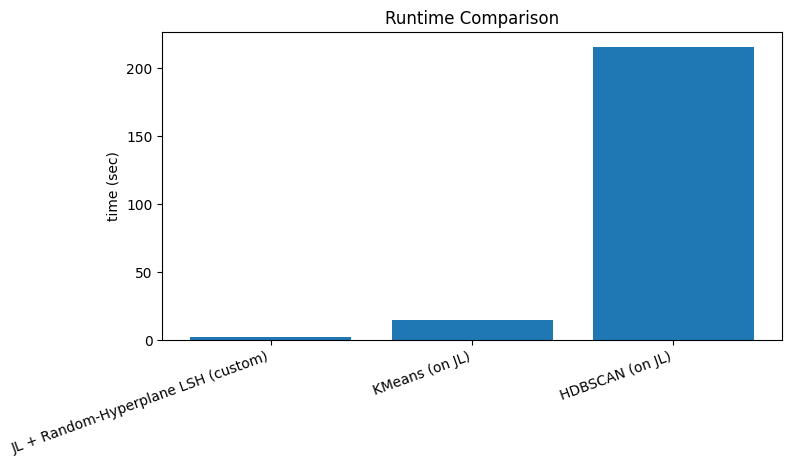

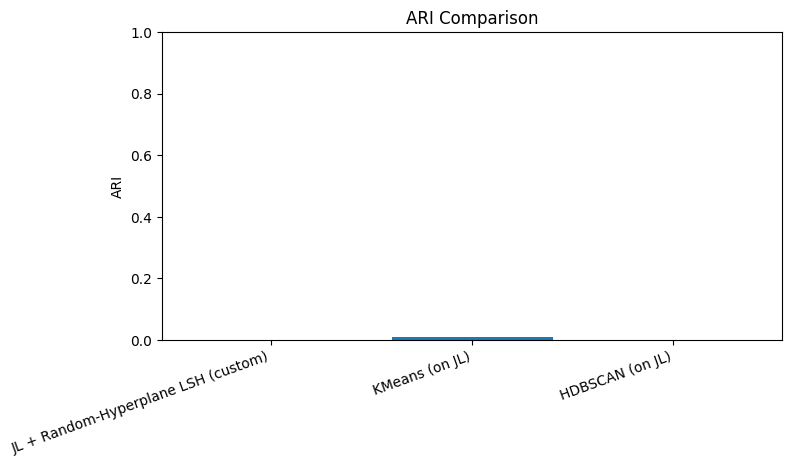

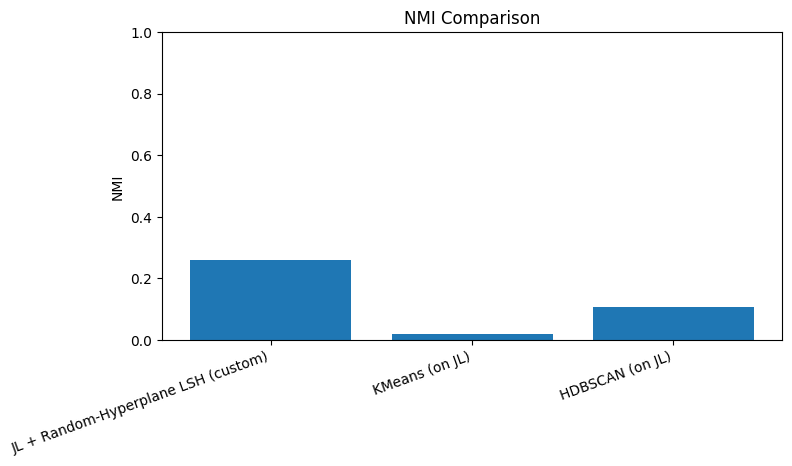

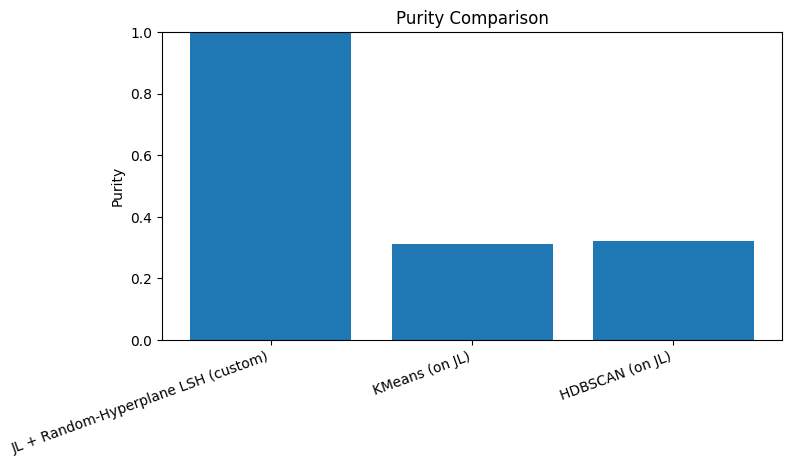

In [12]:
plt.figure(figsize=(8,4))
plt.bar(results["method"], results["time_sec"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("time (sec)")
plt.title("Runtime Comparison")
plt.show()

for metric in ["ARI", "NMI", "Purity"]:
    plt.figure(figsize=(8,4))
    plt.bar(results["method"], results[metric])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1.0)
    plt.show()

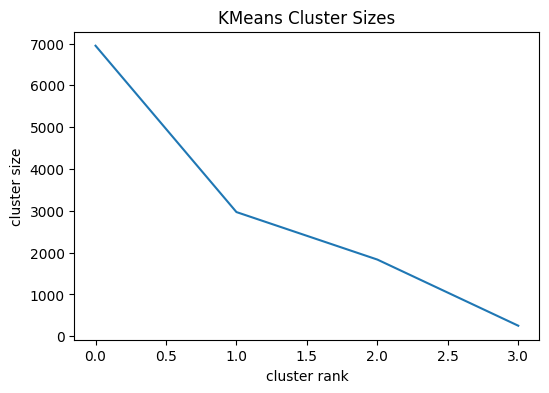

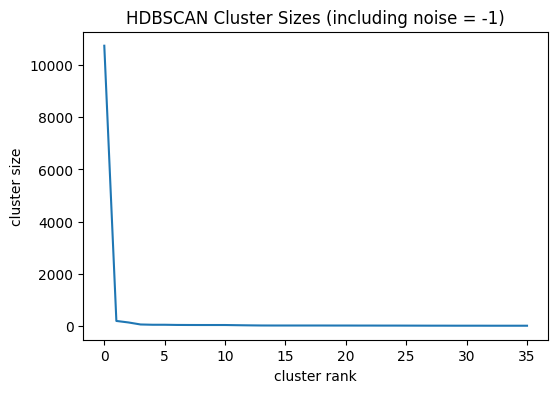

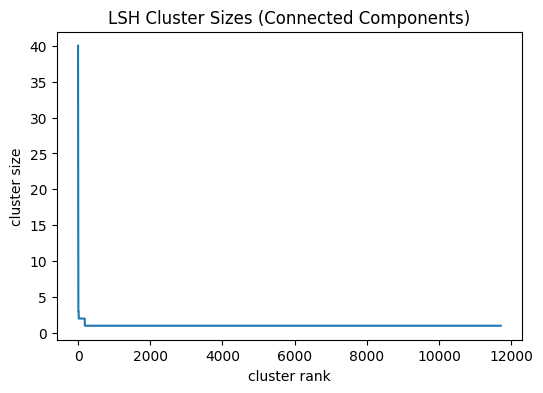

In [13]:
def plot_cluster_sizes(labels, title):
    labels = np.asarray(labels)
    _, counts = np.unique(labels, return_counts=True)
    counts = np.sort(counts)[::-1]
    plt.figure(figsize=(6,4))
    plt.plot(counts)
    plt.xlabel("cluster rank")
    plt.ylabel("cluster size")
    plt.title(title)
    plt.show()

plot_cluster_sizes(y_km, "KMeans Cluster Sizes")

if HDBSCAN_AVAILABLE and y_hdb is not None:
    plot_cluster_sizes(y_hdb, "HDBSCAN Cluster Sizes (including noise = -1)")

plot_cluster_sizes(y_lsh, "LSH Cluster Sizes (Connected Components)")

In [14]:
def corrupt_text(text, drop_prob=0.15, seed=0):
    rng = np.random.default_rng(seed)
    toks = text.split()
    keep = [t for t in toks if rng.random() > drop_prob]
    if len(keep) < 5:
        keep = toks[:5]
    return " ".join(keep)

dup_count = 120
rng = np.random.default_rng(123)
base_idx = rng.choice(len(texts), size=dup_count, replace=False)

dup_texts = [corrupt_text(texts[i], drop_prob=0.20, seed=int(i)) for i in base_idx]
aug_texts = texts + dup_texts

N0 = len(texts)
dup_pairs = [(int(i), N0 + k) for k, i in enumerate(base_idx)]

X_aug = vectorizer.fit_transform(aug_texts)
X_aug = normalize(X_aug, norm="l2", axis=1)

X_aug_jl = rp.fit_transform(X_aug)
X_aug_jl = normalize(X_aug_jl, norm="l2", axis=1)

t0 = time.perf_counter()

bits_aug = random_hyperplane_hash(X_aug_jl, hyperplanes)
tables_aug = lsh_candidate_buckets(bits_aug, band_size=BAND_SIZE)
cand_aug = build_candidate_pairs(tables_aug, max_bucket_size=MAX_BUCKET)

edges_aug = []
for (i, j) in cand_aug:
    if float(np.dot(X_aug_jl[i], X_aug_jl[j])) >= COS_THRESHOLD:
        edges_aug.append((i, j))

labels_aug = connected_components(n=X_aug_jl.shape[0], edges=edges_aug)
dup_time = time.perf_counter() - t0

hits = sum(1 for a, b in dup_pairs if labels_aug[a] == labels_aug[b])
dup_recall = hits / len(dup_pairs)

print("Duplicate recall (LSH components):", dup_recall)
print("Time (LSH on augmented corpus):", dup_time)

Duplicate recall (LSH components): 0.725
Time (LSH on augmented corpus): 1.262195461000033


In [15]:
results.to_csv("experiment2_agnews_results.csv", index=False)
print("Saved: experiment2_agnews_results.csv")

Saved: experiment2_agnews_results.csv
